# Microgrid Module Instruction

## Table of Contents
1. [Introduction](#introduction)
2. [Installation & Setup](#installation--setup)
3. [Understanding the System Components](#understanding-the-system-components)
4. [Data Preparation](#data-preparation)
5. [Basic Usage Example](#basic-usage-example)
6. [Display](#display)

## Introduction

This tutorial demonstrates how to use the BESTOpt 'micro_grid.py' module to optimizes energy flows in a microgrid containing:
- **Building**: Electrical demand from building (HVAC+Lighting+Equipment, etc)
- **Solar PV**: Renewable energy generation
- **Battery Storage**: Battery storage system that can charge/discharge
- **Electric Vehicle**: EV that can charge/discharge
- **Grid**: Utility grid for buying electricity

The system uses Gurobi to minimize electricity costs while satisfying all operational constraints.

## Installation & Setup

### Required Libraries
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Make sure you have these packages installed:
# gurobipy pandas numpy matplotlib seaborn
# Note: Gurobi requires a license (free academic licenses available)
```

### Import the Microgrid Classes
```python
from micro_grid import (
    BatteryConfig, EVConfig, PVConfig, GlobalConfig,
    BuildingConfig, Config, Optimizer
)
```

## Understanding the System Components

### 1. GlobalConfig
Contains environmental and system-wide parameters:
```python
@dataclass
class GlobalConfig:
    T_amb: np.ndarray      # Ambient temperature (°C)
    Sol: np.ndarray        # Solar irradiance (W/m²)
    TOU: np.ndarray        # Time-of-Use electricity prices ($/kWh)
    Res: int               # Time resolution in minutes (e.g., 15 for 15-minute intervals)
    cpus: int              # Number of CPU cores for optimization
```

### 2. Building Components

#### Battery Storage
```python
@dataclass
class BatteryConfig:
    capacity_kwh: float          # Battery capacity (kWh)
    c_rate: float                # Charge/discharge rate (C-rate)
    charge_efficiency: float     # Charging efficiency (0-1)
    discharge_efficiency: float  # Discharging efficiency (0-1)
    min_soc: float               # Minimum state of charge (0-1)
    max_soc: float               # Maximum state of charge (0-1)
    initial_soc: float           # Starting state of charge (0-1)
```

#### Electric Vehicle
```python
@dataclass
class EVConfig:
    capacity_kwh: float             # EV battery capacity (kWh)
    c_rate: float                   # Charge/discharge rate
    arrival_time: int               # When EV arrives (time step)
    departure_time: int             # When EV departs (time step)
    arrival_soc: float              # SOC when arriving (0-1)
    required_departure_soc: float   # Required SOC when leaving (0-1)
    charge_efficiency: float        # Charging efficiency (0-1)
    discharge_efficiency: float     # Discharging efficiency (0-1)
    min_soc: float                  # Minimum state of charge (0-1)
    max_soc: float                  # Maximum state of charge (0-1)
```

#### Solar PV
```python
@dataclass
class PVConfig:
    capacity_kw: float    # PV system capacity (kW)
    pv_gen: np.ndarray    # Generated power
```

## Data Preparation

### Loading Your Dataset
Your data should be a CSV file with the following features:
- Ambient temperature (°C)
- Solar Radiation (W)
- Time-of-use prices ($/kWh)
- Building electrical load (kW)

## Basic Usage Example

In [8]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from DONT_CLICK.old.micro_grid import (
    GlobalConfig,
    Config,
    Optimal_control,
    Rule_control,
)

In [9]:
# Load example data
data = pd.read_csv('example_data/Example_MG.csv')

In [14]:
# Configuration
# Global variables
global_config = GlobalConfig(
    T_amb=data['temp_amb'].values,    # Temperature array
    Sol=data['solar'].values,         # Solar irradiance array
    TOU=data['TOU'].values,           # Time-of-use pricing array
    Res=15,                           # 15-minute resolution
    cpus=16                           # Use 16 CPU cores
)

# Create configuration object
config = Config(global_config)

# Add building and MG components
# Example: Bldg + PV + Battery
# Define PV parameters
pv_params = {
    'capacity_kw': 5  # PV Capacity: 5 kW
}

# Define battery parameters
battery_params = {
    'capacity_kwh': 10.0,         # Battery Capacity: 10 kWh
    'c_rate': 0.25,               # 0.25C charge/discharge rate (4 hours)
    'charge_efficiency': 0.95,    # 95% charging efficiency
    'discharge_efficiency': 0.95, # 95% discharging efficiency
    'min_soc': 0.1,               # 10% minimum SOC
    'max_soc': 0.9,               # 90% maximum SOC
    'initial_soc': 0.5            # Start at 50% SOC
}

# Define ev parameters
ev_params = {
    'capacity_kwh': 50.0,         # EV Capacity: 50 kWh
    'c_rate': 0.25,               # 0.25C charge/discharge rate (4 hours)
    'charge_efficiency': 0.95,    # 95% charging efficiency
    'discharge_efficiency': 0.95, # 95% discharging efficiency
    'min_soc': 0.1,               # 10% minimum SOC
    'max_soc': 1.0,               # 90% maximum SOC
    'departure_time': 8*4,
    'arrival_time': 18*4,
    'arrival_soc': 0.6,
    'required_departure_soc': 0.95
}

# Create building configuration
building = config.create_building(
    load=data['load'].values/1000,  # Assign Building load (Need to be kW)
    pv_params=pv_params,            # Assign PV parameters
    battery_params=battery_params,  # Assign Battery parameters

)

In [15]:
# Use optimal control
Optimal_controller = Optimal_control(building, global_config)
print("Running optimal control...")
opt_results = Optimal_controller.run()
print(f"Optimal control completed!")

# Use rule-based control
Rule_controller = Rule_control(building, global_config)
print("Running rule based control...")
rb_results = Rule_controller.run()
print(f"Rule based control completed!")

Running optimal control...
Optimal control completed!
Running rule based control...
Rule based control completed!


## Display

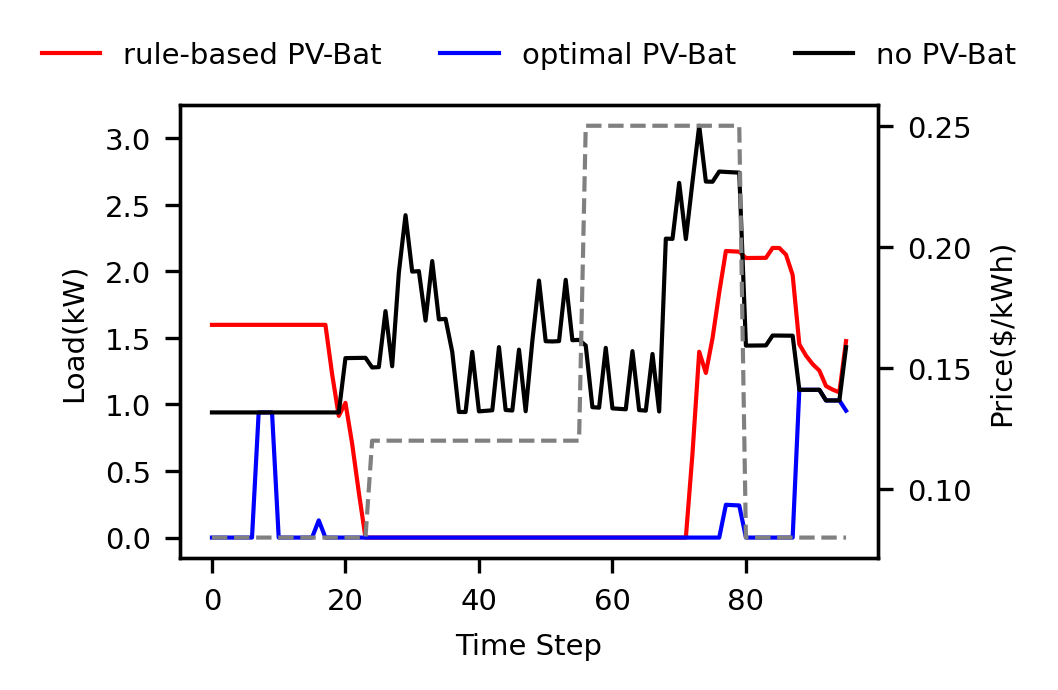

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(np.arange(len(rb_results)), rb_results["GridPurchase"], '-', linewidth=1, color='red', label="rule-based PV-Bat")
ax.plot(np.arange(len(opt_results)), opt_results["GridPurchase"], '-', linewidth=1, color='blue', label="optimal PV-Bat")
ax.plot(np.arange(len(opt_results)), opt_results["Load"], '-', linewidth=1, color='black', label="no PV-Bat")
ax_ = ax.twinx()
ax_.plot(np.arange(len(opt_results)), opt_results["TOU"], '--', linewidth=1, color='gray', label="Price")
ax.grid(False)
ax_.grid(False)
ax.set_ylabel('Load(kW)', fontsize=7)
ax_.set_ylabel('Price($/kWh)', fontsize=7)
ax.tick_params(axis='both', which='both', labelsize=7)
ax_.tick_params(axis='both', which='both', labelsize=7)
ax.set_xlabel('Time Step', fontsize=7)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2),
               ncol=3, fontsize=7, frameon=False)
plt.show()

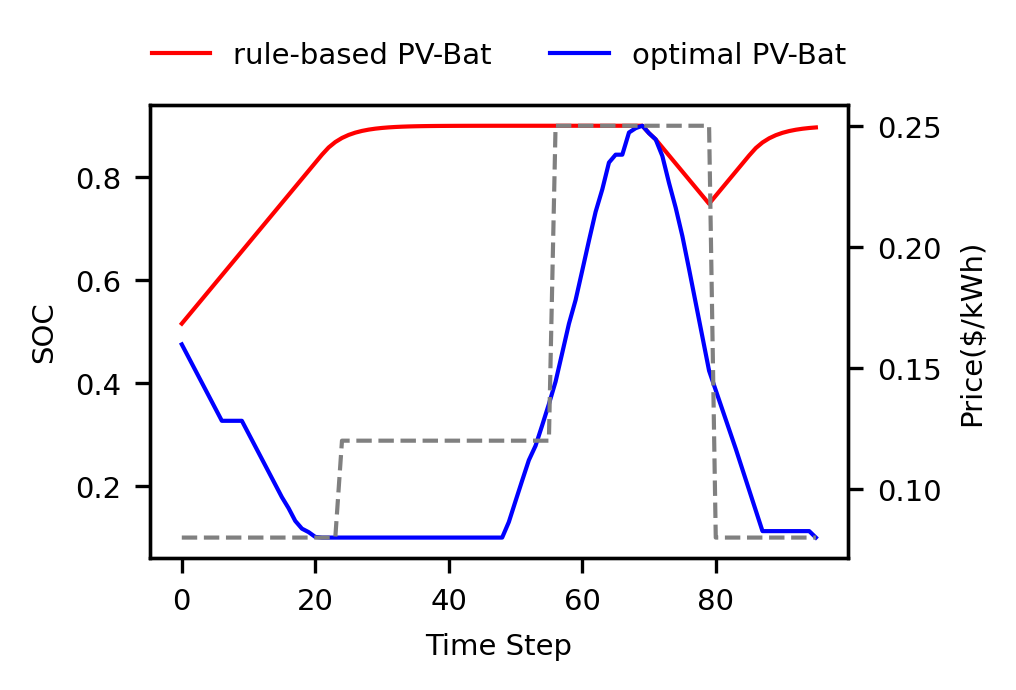

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(np.arange(len(rb_results)), rb_results["SoC_Bat"], '-', linewidth=1, color='red', label="rule-based PV-Bat")
ax.plot(np.arange(len(opt_results)), opt_results["SoC_Bat"], '-', linewidth=1, color='blue', label="optimal PV-Bat")
ax_ = ax.twinx()
ax_.plot(np.arange(len(opt_results)), opt_results["TOU"], '--', linewidth=1, color='gray', label="Price")
ax.grid(False)
ax_.grid(False)
ax.set_ylabel('SOC', fontsize=7)
ax_.set_ylabel('Price($/kWh)', fontsize=7)
ax.tick_params(axis='both', which='both', labelsize=7)
ax_.tick_params(axis='both', which='both', labelsize=7)
ax.set_xlabel('Time Step', fontsize=7)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2),
               ncol=2, fontsize=7, frameon=False)
plt.show()

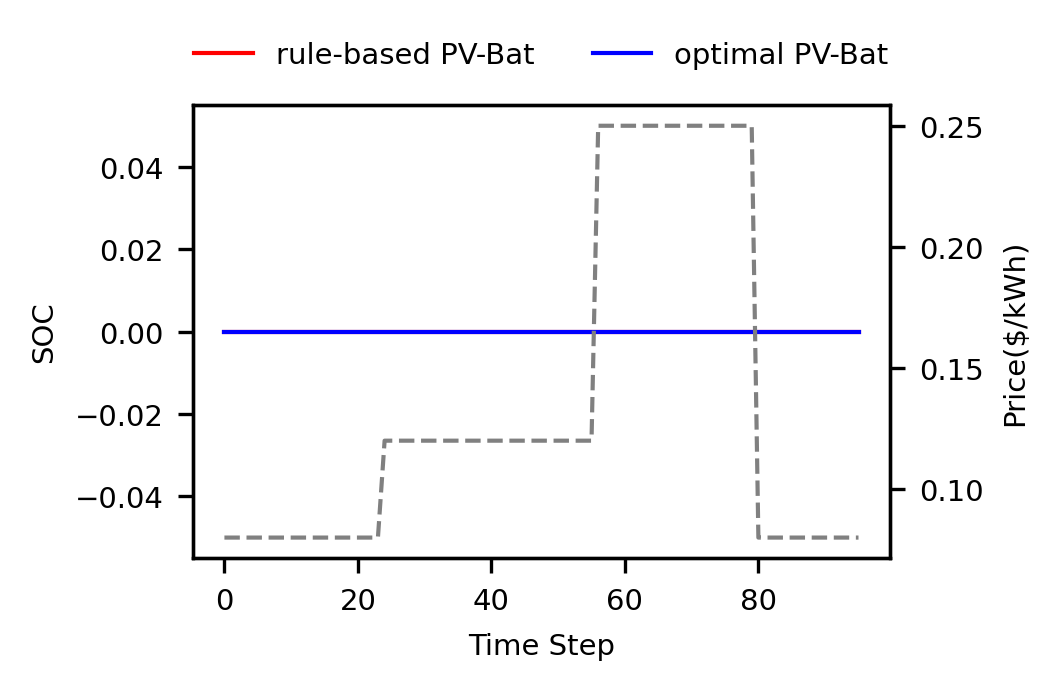

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(np.arange(len(rb_results)), rb_results["SoC_EV"], '-', linewidth=1, color='red', label="rule-based PV-Bat")
ax.plot(np.arange(len(opt_results)), opt_results["SoC_EV"], '-', linewidth=1, color='blue', label="optimal PV-Bat")
ax_ = ax.twinx()
ax_.plot(np.arange(len(opt_results)), opt_results["TOU"], '--', linewidth=1, color='gray', label="Price")
ax.grid(False)
ax_.grid(False)
ax.set_ylabel('SOC', fontsize=7)
ax_.set_ylabel('Price($/kWh)', fontsize=7)
ax.tick_params(axis='both', which='both', labelsize=7)
ax_.tick_params(axis='both', which='both', labelsize=7)
ax.set_xlabel('Time Step', fontsize=7)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2),
               ncol=2, fontsize=7, frameon=False)
plt.show()